# 01. Exploratory Data Analysis & Text Cleaning

**Goal:** Understand the 5 BBC news categories and perform basic cleaning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../../../shared')
from text_utils import clean_text_basic

## 1. Load Data

In [2]:
df = pd.read_csv('../data/raw/dataset.csv', encoding='latin1')
df.rename(columns={'news': 'text', 'type': 'category'}, inplace=True)
print(df.head())
print(df.info())

                                                text  category
0  China had role in Yukos split-up\n \n China le...  business
1  Oil rebounds from weather effect\n \n Oil pric...  business
2  Indonesia 'declines debt freeze'\n \n Indonesi...  business
3  $1m payoff for former Shell boss\n \n Shell is...  business
4  US bank in $515m SEC settlement\n \n Five Bank...  business
<class 'pandas.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   text      2225 non-null   str  
 1   category  2225 non-null   str  
dtypes: str(2)
memory usage: 34.9 KB
None


## 2. Category Distribution

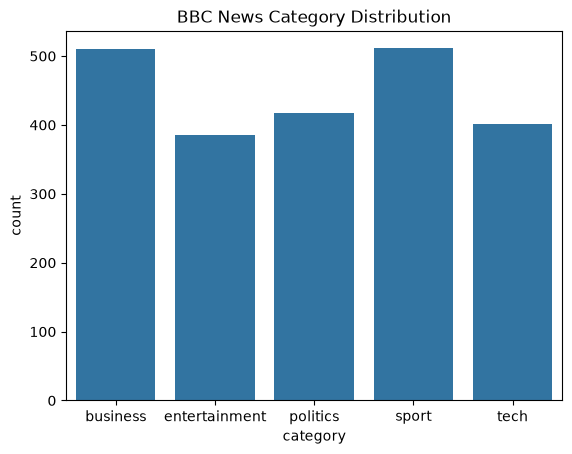

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


In [3]:
sns.countplot(x='category', data=df)
plt.title('BBC News Category Distribution')
plt.show()
print(df['category'].value_counts())

> **📌 Decision Note — Why Basic text cleaning?**
>
> **Chosen approach:** Lowercasing and punctuation removal via custom shared utility
>
> **Why this works:** Creates a clean base for advanced morphological analysis in the next step.
>
> **Alternatives we could have used:**
> | Option | Pros | Cons |
> |--------|------|------|
> | Keep punctuation | Helps with grammar parsing | Irrelevant for simple text classification; increases vocabulary size. |
> | Remove all numbers | Reduces noise | In business/tech news, numbers (e.g. '5G', '2004') can be important features. We'll leave them for now. |
>
> **Why we chose this over alternatives:** Basic cleaning is a necessary prerequisite before stemming or lemmatization.

## 3. Apply Basic Cleaning

In [4]:
df['cleaned_text'] = df['text'].apply(clean_text_basic)
df[['category', 'text', 'cleaned_text']].head()

,category,text,cleaned_text
0,business,China had role in Yukos split-up\n \n China le...,china had role in yukos splitup china lent rus...
1,business,Oil rebounds from weather effect\n \n Oil pric...,oil rebounds from weather effect oil prices re...
2,business,Indonesia 'declines debt freeze'\n \n Indonesi...,indonesia declines debt freeze indonesia no lo...
3,business,$1m payoff for former Shell boss\n \n Shell is...,m payoff for former shell boss shell is to pay...
4,business,US bank in $515m SEC settlement\n \n Five Bank...,us bank in m sec settlement five bank of ameri...


In [5]:
df.to_csv('../data/processed/cleaned_bbc.csv', index=False)
print('Saved cleaned dataset.')

Saved cleaned dataset.
